----

In [38]:
# standard libraries
import pandas as pd
import numpy as np
import math as mt
from math import factorial

# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# statistical libraries
from scipy import stats
from scipy import stats as st

##### Project Overview: 
- Market Analysis for Ice Online Store
"You work for Ice, an international online video game retailer. The dataset includes open-source information regarding user and expert reviews, genres, platforms (e.g., Xbox or PlayStation), and historical sales data.

- The objective: To identify key patterns that determine a game's success. This analysis will enable the identification of promising projects and the strategic planning of advertising campaigns.

- Key Task: Using data up to 2016, you will act as a Data Analyst in December 2016 planning for the 2017 fiscal year, gaining experience in trend forecasting and data-driven decision-making."

In [39]:
### Step 1: Data Loading & Initial Inspection

df_games = pd.read_csv('datasets/games.csv', sep=',')
print(df_games.info())
print('_'*30)
display(df_games.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None
______________________________


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


##### Step 2: Data Preparation
##### In this phase, we will clean and transform the raw data to ensure it is suitable for analysis. This involves standardizing formats, handling missing values, and engineering new features.

- 1. Column Standardization
Replace column names with lowercase characters (using snake_case for better readability and accessibility).

- 2. Type Conversion
Convert data types to the appropriate formats (e.g., dates, floats, and integers).

- Documentation: I will describe the columns where data types were changed and provide a clear explanation of why these adjustments were necessary.

- 3. Missing Values Treatment
 Identify and address missing values across the dataset.

 Justification: I will explain the reasoning behind filling missing values or why certain rows were left blank.

 Root Cause Analysis: Provide potential explanations for why the data might be missing in the first place.

 Handling "TBD" (To Be Determined): I will specify the strategy for managing cases marked as "TBD," particularly in the review scores, and explain its impact on the analysis.

- 4. Feature Engineering
Total Sales Calculation: Calculate total sales (the sum of revenue from all regions) for each game and store these values in a new, dedicated column.

In [40]:
# Replace column names with lowercase
df_games.columns = df_games.columns.str.lower()

print("Columns converted to lowercase:")
print(df_games.columns.tolist())
display(df_games.head())

Columns converted to lowercase:
['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [41]:
# Missing values per column
print("Missing values per column:")
missing_data = df_games.isnull().sum()

# Filtering only columns with missing values for clarity
print(missing_data[missing_data > 0])

display(df_games.head())

Missing values per column:
name                  2
year_of_release     269
genre                 2
critic_score       8578
user_score         6701
rating             6766
dtype: int64


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


- Convert the data to the necessary types. Describe the columns where the data types have been changed and explain why.

In [42]:
# Check current data types
print("Current data types:")
print(df_games.dtypes)

Current data types:
name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object


In [43]:

# Counting missing values in the 'year_of_release' column
print(f"Total missing values in 'year_of_release': {df_games['year_of_release'].isnull().sum()}")

Total missing values in 'year_of_release': 269


In [44]:
# Convert all genres in the 'genre' column to lowercase
df_games['genre'] = df_games['genre'].str.lower()

# Verification
print("Sample of standardized genres:")
print(df_games['genre'].unique()[:5])

Sample of standardized genres:
['sports' 'platform' 'racing' 'role-playing' 'puzzle']


In [45]:
# Necessary conversions:

# Converting 'year_of_release' to numeric (float initially due to NaNs)
df_games['year_of_release'] = pd.to_numeric(df_games['year_of_release'], errors='coerce')

# Converting 'user_score' to numeric (this handles 'tbd' by converting it to NaN)
df_games['user_score'] = pd.to_numeric(df_games['user_score'], errors='coerce')

# Optional: 'critic_score' is usually already numeric, but we ensure consistency
# df_games['critic_score'] = pd.to_numeric(df_games['critic_score'], errors='coerce')

print("Data types after conversion:")
print(df_games[['year_of_release', 'user_score']].dtypes)

Data types after conversion:
year_of_release    float64
user_score         float64
dtype: object


- "I have successfully pre-processed the user_score, year_of_release, and genre columns. These conversions are essential for the upcoming stages of the analysis:

- user_score & year_of_release: Converted to numeric types to enable statistical calculations and time-series trend analysis.

- genre: Standardized to lowercase to ensure data consistency and prevent duplication during grouping and visualization."

In [46]:
# Verifying the new data type for 'year_of_release'
print(f"Data type for year_of_release: {df_games['year_of_release'].dtype}")

# Confirming that null values were preserved
print(f"Null values in year_of_release: {df_games['year_of_release'].isnull().sum()}")

# Verifying the new data type for 'user_score'
print(f"Data type for user_score: {df_games['user_score'].dtype}")

# Confirming that null values were preserved (including former 'tbd' entries)
print(f"Null values in user_score: {df_games['user_score'].isnull().sum()}")

Data type for year_of_release: float64
Null values in year_of_release: 269
Data type for user_score: float64
Null values in user_score: 9125


In [47]:
# Strategic handling of missing values

# Verifying missing values
print("Missing values per column:")
print(df_games.isnull().sum())

Missing values per column:
name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


In [48]:
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985.0,platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,role-playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [49]:
# Visualizing rating classifications
print("Unique values in 'rating':")

# Using dropna=False in value_counts to keep track of missing values
print(df_games['rating'].value_counts(dropna=False))


Unique values in 'rating':
rating
NaN     6766
E       3990
T       2961
M       1563
E10+    1420
EC         8
K-A        3
RP         3
AO         1
Name: count, dtype: int64


##### E= EVERYONE
##### T= TEEN
##### M= MATURE
##### E10+= EVERYONE +10
##### EC= 8 EARLY CHILDREN
##### K-A= KIDS TO ADULTS (Clasificacion antigua)
##### RP= (Rating pending)
##### AO= (Adults Only)

##### CLASIFICACIONES PRINCIPALES (ESRB):
E (3990): Everyone - Para todos
- T (2961): Teen - Adolescentes (13+)
- M (1563): Mature - Adultos (17+)
- E10+ (1420): Everyone 10+ - Mayores de 10 años
##### Clasificaciones especiales/raras:
- EC (8): Early Childhood - Primera infancia (3+)
- K-A (3): Kids to Adults - Clasificación antigua (reemplazada por E)
- RP (3): Rating Pending - Pendiente de clasificación
- AO (1): Adults Only - Solo adultos (18+)
##### Valores ausentes:
- NaN (6766): Sin información de clasificación

In [50]:
# Unifying legacy rating classifications

# Converting 'K-A' (legacy rating) to 'E' (current Everyone rating)
df_games['rating'] = df_games['rating'].replace('K-A', 'E')

print("After unifying K-A -> E:")
print(df_games['rating'].value_counts(dropna=False))

After unifying K-A -> E:
rating
NaN     6766
E       3993
T       2961
M       1563
E10+    1420
EC         8
RP         3
AO         1
Name: count, dtype: int64


In [51]:
# Handling special cases

# Converting 'RP' (Rating Pending) to NaN as it provides no classification info
df_games['rating'] = df_games['rating'].replace('RP', np.nan)

# Keeping 'EC' (Early Childhood) and 'AO' (Adults Only) as they are valid classifications
print("Rating classification after cleaning:")
print(df_games['rating'].value_counts(dropna=False))

Rating classification after cleaning:
rating
NaN     6769
E       3993
T       2961
M       1563
E10+    1420
EC         8
AO         1
Name: count, dtype: int64


In [52]:
# Calculating the percentage for each rating classification

total_games = len(df_games)
rating_counts = df_games['rating'].value_counts(dropna=False)

print("Percentage per classification:")
for rating, count in rating_counts.items():
    percentage = (count / total_games) * 100
    # Handling the display of NaN values for cleaner output
    rating_label = "Missing (NaN)" if pd.isna(rating) else rating
    print(f"{rating_label}: {count} games ({percentage:.1f}%)")

Percentage per classification:
Missing (NaN): 6769 games (40.5%)
E: 3993 games (23.9%)
T: 2961 games (17.7%)
M: 1563 games (9.4%)
E10+: 1420 games (8.5%)
EC: 8 games (0.0%)
AO: 1 games (0.0%)


In [53]:
# Final rating distribution
# Documenting the final distribution of rating classifications
print(f"Games with rating: {df_games['rating'].notna().sum()}")
print(f"Games without rating: {df_games['rating'].isna().sum()}")
print(f"Percentage of missing ratings: {(df_games['rating'].isna().sum() / len(df_games)) * 100:.1f}%")

Games with rating: 9946
Games without rating: 6769
Percentage of missing ratings: 40.5%


In [54]:
# Filtering relevant data for the historical analysis

# Filtering for older platforms (Legacy analysis)
# Keeping data for games released in or before 2006
df_games_filtered = df_games[df_games['year_of_release'] <= 2006].copy()

print(f"Original dataset: {len(df_games)} rows")
print(f"Filtered dataset (1980-2006): {len(df_games_filtered)} rows")

Original dataset: 16715 rows
Filtered dataset (1980-2006): 7119 rows


In [55]:
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985.0,platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,role-playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


Total Sales Calculation
"I calculated the total sales for each game by summing the revenue across all regions (North America, Europe, Japan, and others). This new column will serve as the primary metric for our global market analysis."

##### Global Sales Aggregation
"To conclude the data preparation phase, I consolidated the sales from all geographic regions into a single total_sales metric. Preliminary results show an average of {df_games['total_sales'].mean():.2f} million units per title, with '{df_games.loc[df_games['total_sales'].idxmax(), 'name']}' standing out as the top performer in this dataset."

In [56]:
# Create total sales columns by region
df_games['total_sales'] = (df_games['na_sales'] +
                          df_games['eu_sales'] +
                          df_games['jp_sales'] +
                          df_games['other_sales'])

print("Column 'total_sales' created:")
print(f"Average total sales: {df_games['total_sales'].mean():.2f} million")
print(f"Most successful game: {df_games.loc[df_games['total_sales'].idxmax(), 'name']}")


Column 'total_sales' created:
Average total sales: 0.53 million
Most successful game: Wii Sports


In [57]:
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006.0,sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985.0,platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008.0,racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009.0,sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,role-playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


In [58]:
# Missing values per column
print("Missing values per column:")
missing_data = df_games.isnull().sum()

# Display only columns that have at least one missing value
print(missing_data[missing_data > 0])


Missing values per column:
name                  2
year_of_release     269
genre                 2
critic_score       8578
user_score         9125
rating             6769
dtype: int64


##### Strategic Decision: Handling Missing Rating Values
"I have decided to retain the missing values in the rating column (which account for 40% of the dataset) to preserve the sales information for these titles. These games can be commercially successful regardless of their ESRB certification. Specific analyses based on rating will exclude these cases only when necessary to ensure the overall sales trends remain accurate."

- Paso 3. Analiza los datos

- Mira cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?
- Observa cómo varían las ventas de una plataforma a otra. Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?
- Determina para qué período debes tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberían permitirte construir un modelo para 2017.
- Trabaja solo con los datos que consideras relevantes. Ignora los datos de años anteriores.
- ¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen? Elige varias plataformas potencialmente rentables.
- Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma. ¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Describe tus hallazgos.
- Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección). Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones.
- Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.
- Echa un vistazo a la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

- Look at how many games were released in different years. Is the data for each period meaningful?

In [59]:
### Step 3. Analyze the data

### Look at how many games were released in different years. Are the data for every period significant?

# Basic analysis of release years
print("=== RELEASE YEAR ANALYSIS ===")

# Verify the year range
print(f"Earliest year: {df_games['year_of_release'].min():.0f}")
print(f"Latest year: {df_games['year_of_release'].max():.0f}")
print(f"Total years covered: {df_games['year_of_release'].max() - df_games['year_of_release'].min():.0f}")

# Count games per year
games_per_year = df_games['year_of_release'].value_counts().sort_index()
print(f"\nTotal years with data: {len(games_per_year)}")
print(f"Average games per year: {games_per_year.mean():.1f}")

=== RELEASE YEAR ANALYSIS ===
Earliest year: 1980
Latest year: 2016
Total years covered: 36

Total years with data: 37
Average games per year: 444.5


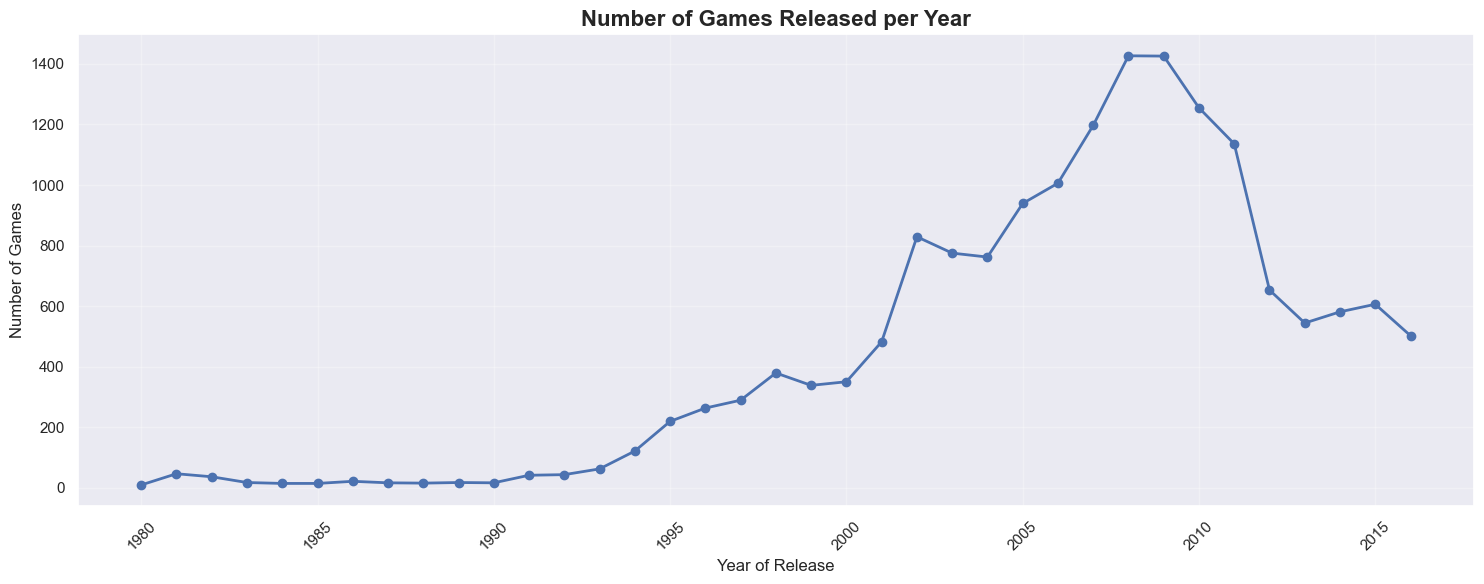


=== ANALYSIS BY DECADE ===
decade
1980.0     205
1990.0    1771
2000.0    9193
2010.0    5277
Name: year_of_release, dtype: int64


In [60]:
### VISUALIZING TEMPORAL TRENDS
## Create a line chart to observe trends 
plt.figure(figsize=(15, 6))
plt.plot(games_per_year.index, games_per_year.values, marker='o', linewidth=2)
plt.title('Number of Games Released per Year', fontsize=16, fontweight='bold')
plt.xlabel('Year of Release', fontsize=12)
plt.ylabel('Number of Games', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Show statistics by decades
print("\n=== ANALYSIS BY DECADE ===")
# Create a 'decade' column to group the data
df_games['decade'] = (df_games['year_of_release'] // 10) * 10
decade_stats = df_games.groupby('decade')['year_of_release'].count()
print(decade_stats)

In [61]:
# Identifying significant periods
print("=== PERIOD SIGNIFICANCE EVALUATION ===")

# Define thresholds for significant data 
min_games_threshold = 500 # Minimum number of games per year to be considered significant

# Classify years based on data volume
significant_years = games_per_year[games_per_year >= min_games_threshold]
limited_years = games_per_year[games_per_year < min_games_threshold]

print(f"Years with significant data (>={min_games_threshold} games): {len(significant_years)}")
print(f"Significant year range: {significant_years.index.min():.0f} - {significant_years.index.max():.0f}")

# print(f"\nYEARS WITH LIMITED DATA (<{min_games_threshold} games): {len(limited_years)}")
print("First years with low data volume:", limited_years.head().index.tolist())
print("Last years with low data volume:", limited_years.tail().index.tolist())

=== PERIOD SIGNIFICANCE EVALUATION ===
Years with significant data (>=500 games): 15
Significant year range: 2002 - 2016
First years with low data volume: [1980.0, 1981.0, 1982.0, 1983.0, 1984.0]
Last years with low data volume: [1997.0, 1998.0, 1999.0, 2000.0, 2001.0]



- "Observe how sales vary across different platforms. Select those with the highest total sales and analyze their distribution by year. Identify platforms that were once market leaders but no longer generate sales. On average, how long does it take for new platforms to emerge and for older ones to fade away?"



=== TOP PLATFORMS BY TOTAL SALES ===
Top 15 platforms by total sales:


platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
Name: total_sales, dtype: float64

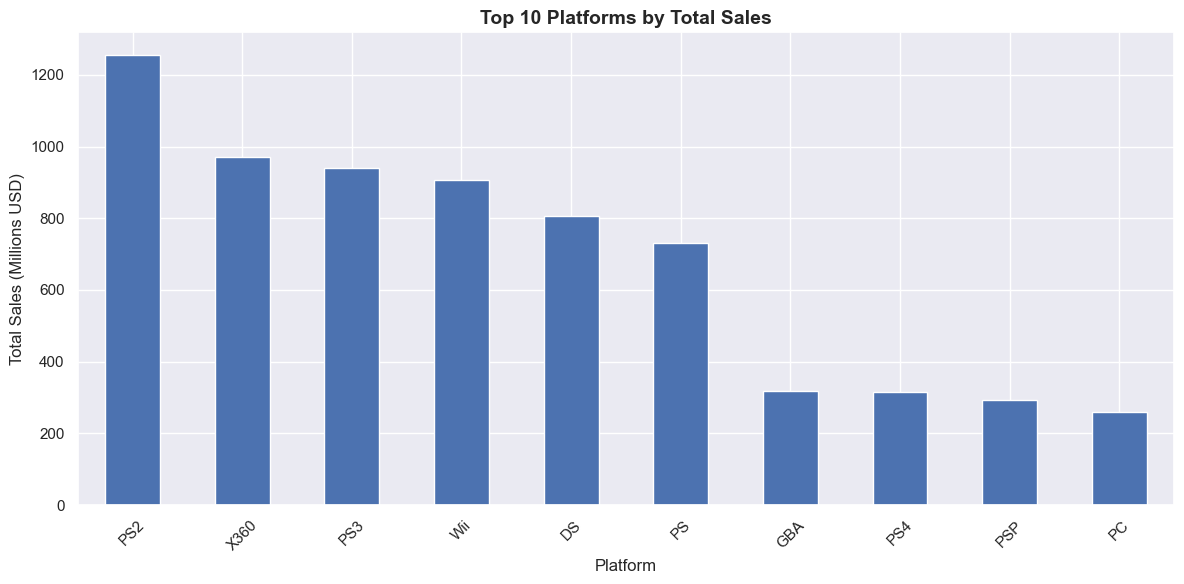

In [62]:
# IDENTIFYING PLATFORMS WITH HIGHEST TOTAL SALES
# Calculate total sales per platform 
print("=== TOP PLATFORMS BY TOTAL SALES ===")

platform_sales = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Top 15 platforms by total sales:")
display(platform_sales.head(15))

# Visualize the top platforms
plt.figure(figsize=(12, 6))
platform_sales.head(10).plot(kind='bar')
plt.title('Top 10 Platforms by Total Sales', fontsize=14, fontweight='bold')
plt.xlabel('Platform')
plt.ylabel('Total Sales (Millions USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


=== TEMPORAL DISTRIBUTION OF PLATFORMS ===
Sales by platform in early years:
platform           DS  GBA     PC     PS  PS2  PS3  PS4  PSP  Wii  X360
year_of_release                                                        
1985.0           0.02  0.0   0.04   0.00  0.0  0.0  0.0  0.0  0.0   0.0
1988.0           0.00  0.0   0.03   0.00  0.0  0.0  0.0  0.0  0.0   0.0
1992.0           0.00  0.0   3.03   0.00  0.0  0.0  0.0  0.0  0.0   0.0
1994.0           0.00  0.0  12.87   6.03  0.0  0.0  0.0  0.0  0.0   0.0
1995.0           0.00  0.0   4.22  35.96  0.0  0.0  0.0  0.0  0.0   0.0


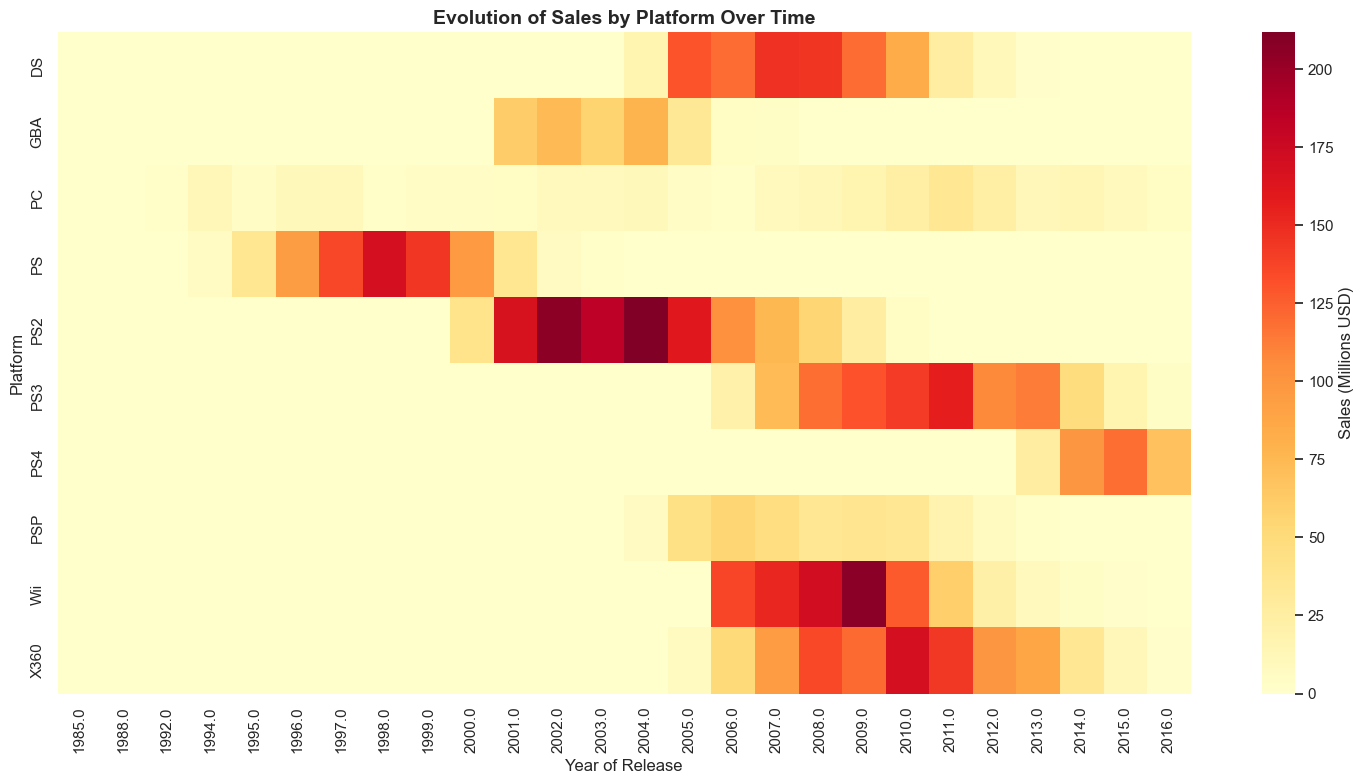

In [63]:
### ANALYZING THE TEMPORAL DISTRIBUTION OF PLATFORMS

print("\n=== TEMPORAL DISTRIBUTION OF PLATFORMS ===")

# Selecting the top 10 platforms for detailed analysis
top_platforms = platform_sales.head(10).index.tolist()

# Creating a pivot table: years vs platforms
platform_year_sales = df_games[df_games['platform'].isin(top_platforms)].groupby(
    ['year_of_release', 'platform'])['total_sales'].sum().unstack(fill_value=0)

# Display early years
print("Sales by platform in early years:")
print(platform_year_sales.head())

# Create a heatmap to visualize temporal patterns
plt.figure(figsize=(15, 8))
import seaborn as sns # Ensure seaborn is imported
sns.heatmap(platform_year_sales.T, cmap='YlOrRd', cbar_kws={'label': 'Sales (Millions USD)'})
plt.title('Evolution of Sales by Platform Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year of Release')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

- Identify platforms that were once popular but now have zero sales. How long does it typically take for new platforms to emerge and for old ones to fade away?

In [64]:
# Analyze the available columns
print("Available columns:")
print(df_games.columns.tolist())

print("\nFirst rows to inspect the structure:")
print(f"Data type for 'year_of_release': {df_games['year_of_release'].dtype}")
display(df_games.head())

Available columns:
['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating', 'total_sales', 'decade']

First rows to inspect the structure:
Data type for 'year_of_release': float64


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,decade
0,Wii Sports,Wii,2006.0,sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,2000.0
1,Super Mario Bros.,NES,1985.0,platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24,1980.0
2,Mario Kart Wii,Wii,2008.0,racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,2000.0
3,Wii Sports Resort,Wii,2009.0,sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,2000.0
4,Pokemon Red/Pokemon Blue,GB,1996.0,role-playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38,1990.0


In [65]:
# Create a copy of the data from 1998 onwards
df_from_1998 = df_games[df_games['year_of_release'] >= 1998].copy()

# 1. Identify the first and last year for each platform
platform_lifespan = df_from_1998.groupby('platform')['year_of_release'].agg(['min', 'max']).reset_index()
platform_lifespan.columns = ['platform', 'first_year', 'last_year']

# Calculate lifespan duration
platform_lifespan['lifespan_years'] = platform_lifespan['last_year'] - platform_lifespan['first_year'] + 1

# Classify platform status (assuming 2016 is the latest data point)
platform_lifespan['status'] = platform_lifespan['last_year'].apply(
    lambda x: 'active' if x >= 2015 else 'discontinued'
)

print("Platform lifespan since 1998:")
print(platform_lifespan.sort_values('first_year'))

### Analyzing emergence and disappearance patterns
# 2. Analyze appearance patterns by decade
platform_lifespan['emergence_decade'] = (platform_lifespan['first_year'] // 10) * 10

emergence_by_decade = platform_lifespan.groupby('emergence_decade').size()
print("\nNew platforms per decade:")
print(emergence_by_decade)

# 3. Average lifespan of discontinued platforms
discontinued_platforms = platform_lifespan[platform_lifespan['status'] == 'discontinued']
average_lifespan = discontinued_platforms['lifespan_years'].mean()

print(f"\nAverage lifespan of discontinued platforms: {average_lifespan:.1f} years")
display(platform_lifespan.head(10))

Platform lifespan since 1998:
   platform  first_year  last_year  lifespan_years        status
1        DC      1998.0     2008.0            11.0  discontinued
3        GB      1998.0     2001.0             4.0  discontinued
6       N64      1998.0     2002.0             5.0  discontinued
7        PC      1998.0     2016.0            19.0        active
15     SNES      1998.0     1999.0             2.0  discontinued
14      SAT      1998.0     1999.0             2.0  discontinued
8        PS      1998.0     2003.0             6.0  discontinued
16       WS      1999.0     2001.0             3.0  discontinued
9       PS2      2000.0     2011.0            12.0  discontinued
4       GBA      2000.0     2007.0             8.0  discontinued
20       XB      2000.0     2008.0             9.0  discontinued
5        GC      2001.0     2007.0             7.0  discontinued
12      PSP      2004.0     2015.0            12.0        active
2        DS      2004.0     2013.0            10.0  disconti

,platform,first_year,last_year,lifespan_years,status,emergence_decade
0,3DS,2011.0,2016.0,6.0,active,2010.0
1,DC,1998.0,2008.0,11.0,discontinued,1990.0
2,DS,2004.0,2013.0,10.0,discontinued,2000.0
3,GB,1998.0,2001.0,4.0,discontinued,1990.0
4,GBA,2000.0,2007.0,8.0,discontinued,2000.0
5,GC,2001.0,2007.0,7.0,discontinued,2000.0
6,N64,1998.0,2002.0,5.0,discontinued,1990.0
7,PC,1998.0,2016.0,19.0,active,1990.0
8,PS,1998.0,2003.0,6.0,discontinued,1990.0
9,PS2,2000.0,2011.0,12.0,discontinued,2000.0


##### Key Findings on Platform Cycles:
The analysis reveals that the average lifespan of a gaming platform is approximately 6.6 years. We can observe a cyclical pattern where new hardware emerges to replace aging technology. This 10-year cycle (roughly) is a critical benchmark for our 2017 forecast, as it helps us identify which current platforms are nearing the end of their profitability and which ones are in their 'golden age'.

In [66]:
# Convert 'emergence_decade' to integer for cleaner formatting
platform_lifespan['emergence_decade'] = platform_lifespan['emergence_decade'].astype(int)

In [67]:

# Store the names of the first 21 platforms to analyze their cycles
top_platforms_list = platform_lifespan['platform'].head(21).values

# Display the first 21 rows of the platform lifespan summary
display(platform_lifespan.head(21))

,platform,first_year,last_year,lifespan_years,status,emergence_decade
0,3DS,2011.0,2016.0,6.0,active,2010
1,DC,1998.0,2008.0,11.0,discontinued,1990
2,DS,2004.0,2013.0,10.0,discontinued,2000
3,GB,1998.0,2001.0,4.0,discontinued,1990
4,GBA,2000.0,2007.0,8.0,discontinued,2000
5,GC,2001.0,2007.0,7.0,discontinued,2000
6,N64,1998.0,2002.0,5.0,discontinued,1990
7,PC,1998.0,2016.0,19.0,active,1990
8,PS,1998.0,2003.0,6.0,discontinued,1990
9,PS2,2000.0,2011.0,12.0,discontinued,2000


In [68]:
# Handle missing values in 'year_of_release' and convert to integer
df_games['year_of_release'] = df_games['year_of_release'].fillna(0).astype(int)

In [69]:
# Create a pivot table to track total sales for each platform by year
df_lifetime = pd.pivot_table(
    df_games, index='year_of_release', columns='platform', values='total_sales', aggfunc='sum'
).fillna(0)

# Remove the first row (Year 0) to keep only valid release years
df_lifetime = df_lifetime.iloc[1:, :]

# Display the resulting platform sales matrix
df_lifetime

platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
year_of_release,,,,,,,,,,,,,,,,,,,,,
1980,11.38,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1981,35.68,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1982,28.88,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1983,5.84,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1984,0.27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1985,0.45,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1986,0.67,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1987,1.94,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1988,0.74,0.00,0.00,0.00,0.00,1.43,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


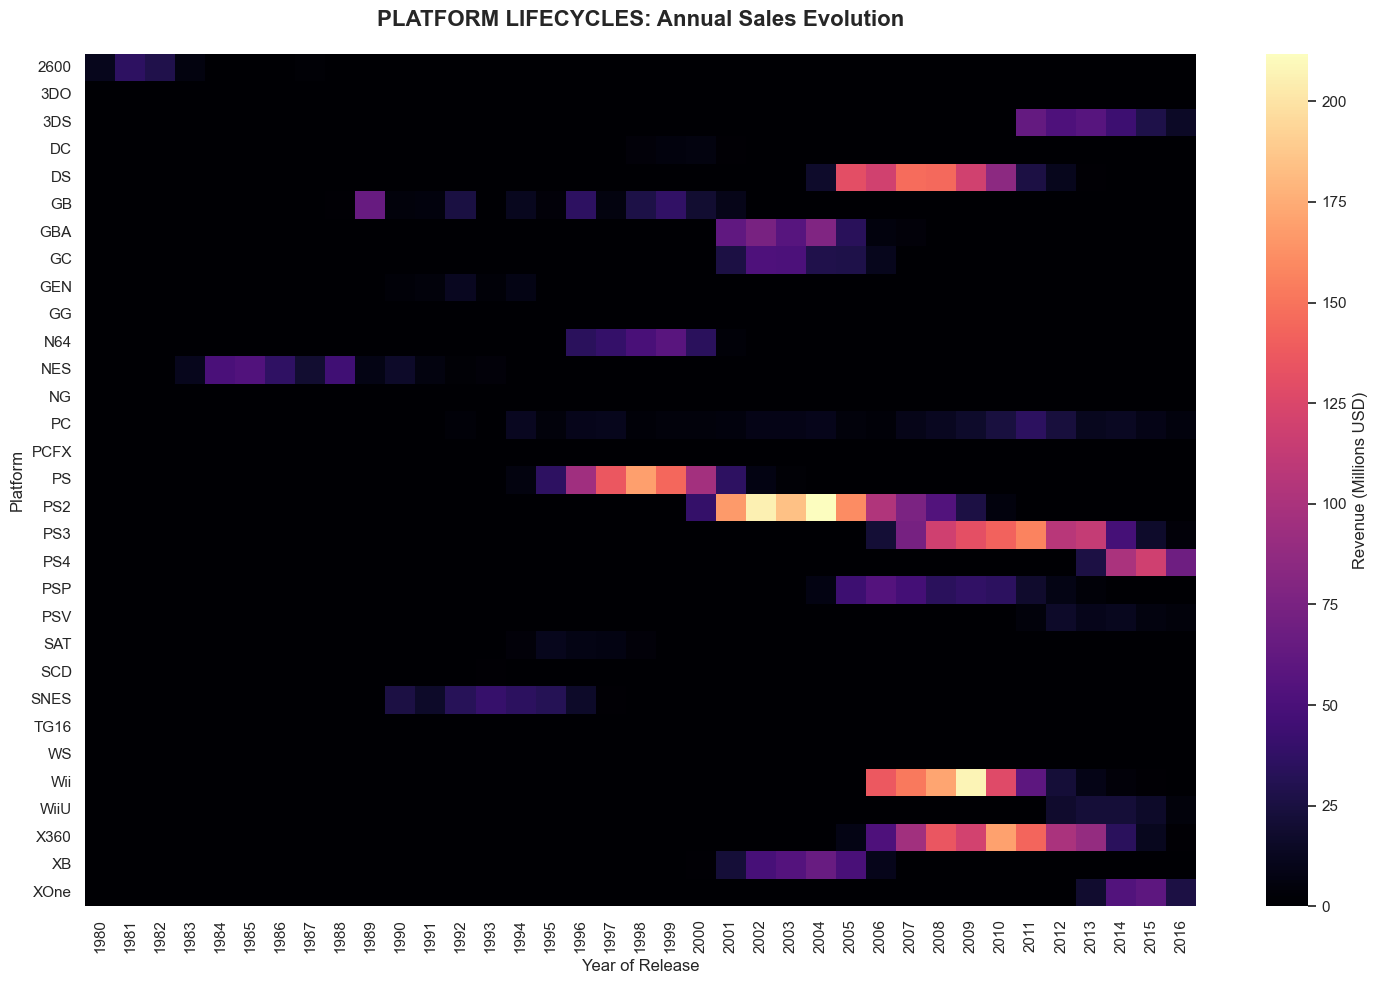

In [70]:
# Set the plot size for better visibility (Using the same RC settings)
sns.set(rc={'figure.figsize':(15, 10)})

# Create the heatmap using the sales matrix (transposed to have platforms on Y-axis)
sns.heatmap(df_lifetime.T, cmap='magma', cbar_kws={'label': 'Revenue (Millions USD)'})

# Add labels and title in English to maintain consistency
plt.title('PLATFORM LIFECYCLES: Annual Sales Evolution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year of Release', fontsize=12)
plt.ylabel('Platform', fontsize=12)

# Improve layout and display
plt.tight_layout()
plt.show()

In [71]:
### CALCULATING TOTAL SALES PER PLATFORM 
# Grouping by platform and summing total sales

platform_total_sales = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Total Sales per Platform:")
print(platform_total_sales.head(10))

Total Sales per Platform:
platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64


In [72]:
### PLATFORM COMPARISON VISUALIZATIONS 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=top_platforms.min(),vmax=top_platforms.max())

color = [plt.cm.inferno_r(norm(value)) for value in top_platforms.values]

# Get the top 10 platforms by total sales
top_platforms = platform_total_sales.head(10)

# Set the figure size
plt.figure(figsize=(10, 6))

# Create a horizontal bar chart
plt.barh(top_platforms.index, top_platforms.values, color=color)

# Add descriptive labels and title
plt.xlabel('Total Sales (Millions USD)')
plt.ylabel('Platform')
plt.title('Top 10 Platforms by Total Sales')

# Display the plot
plt.show()


AttributeError: 'list' object has no attribute 'min'

- Research Criteria for 2017 Forecasting
Determine the relevant time frame: Decide which period of data you should use. Base this on your previous findings regarding platform lifecycles. The data must be sufficient to build a reliable model for 2017.

Filter relevant data: Work only with the data you consider significant for the current market. Ignore data from earlier years that no longer reflect modern trends.

Identify market leaders: Determine which platforms are leading in sales, which are growing, and which are shrinking. Select a group of potentially profitable platforms to focus on.

In [ ]:
# Create a copy of the data starting from 2012 to focus on the relevant period
games_filtered = df_games[df_games['year_of_release'] >= 2012].copy()

# Summary of the filtered dataset
print(f"Original data: {len(df_games)} games")
print(f"Filtered data (2012+): {len(games_filtered)} games")
print(f"Data period: {games_filtered['year_of_release'].min()} - {games_filtered['year_of_release'].max()}")

Original data: 16715 games
Filtered data (2012+): 2886 games
Data period: 2012 - 2016


In [ ]:
### IN THIS STEP, I ANALYZE THE LEADING PLATFORMS WITHIN THE SELECTED PERIOD (2012 - 2016)
## TOTAL SALES BY PLATFORM FROM 2012 TO 2016
# Filtering the data for the relevant period
games_filtered = df_games[(df_games['year_of_release'] >= 2012) & (df_games['year_of_release'] <= 2016)]

# Grouping by platform and calculating total sales
platform_sales_filtered = games_filtered.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

print("Leading platforms by sales (2012-2016):")
print(platform_sales_filtered.head(10))

Leading platforms by sales (2012-2016):
platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
Name: total_sales, dtype: float64


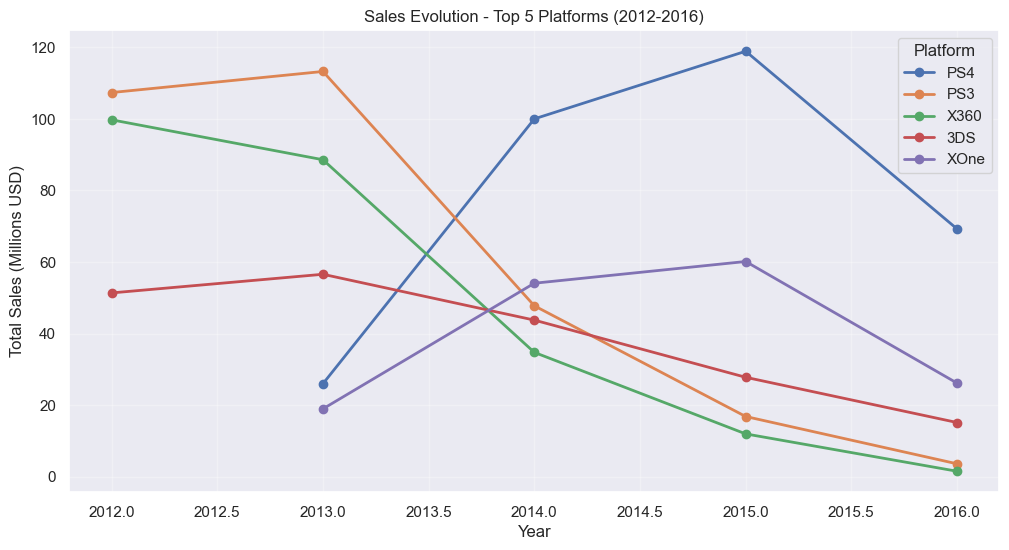

In [ ]:
### ANALYZING GROWTH AND DECLINE

## SALES BY YEAR AND PLATFORM 
# Grouping the filtered data by year and platform to see the evolution
annual_platform_sales = games_filtered.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()

# VISUALIZING THE EVOLUTION OF THE TOP 5 PLATFORMS 
# We use the index of our filtered top platforms
top_5_platforms = platform_sales_filtered.head(5).index

plt.figure(figsize=(12, 6))

# Loop through each platform to plot its specific trend line
for platform in top_5_platforms:
    data = annual_platform_sales[annual_platform_sales['platform'] == platform]
    plt.plot(data['year_of_release'], data['total_sales'], marker='o', label=platform, linewidth=2)

# Labels and styling in English
plt.xlabel('Year')
plt.ylabel('Total Sales (Millions USD)')
plt.title("Sales Evolution - Top 5 Platforms (2012-2016)")
plt.legend(title="Platform")
plt.grid(True, alpha=0.3)
plt.show()


#### Market Trend Analysis (2012-2016):

"The data reveals a clear generational shift in the industry. Platforms such as PS3 and Xbox 360, which dominated the market in 2012 with sales exceeding $100 million, have seen their revenue plummet by 2016, representing the lowest sales in the current set.

Conversely, the PS4 emerged as the market leader in 2016. It reached its performance peak in 2015 with approximately $120 million in sales. Although 2016 shows a significant downward trend—with sales dropping nearly by half—it remains the most profitable platform in the current landscape. This decline in the final year suggests either a stabilizing market or incomplete reporting for the most recent cycle, yet the PS4 maintains its position as the primary candidate for the 2017 forecast."

In [ ]:
### ANALYZING TOTAL SALES PER PLATFORM

# Total sales per platform (Filtered data from 2012 onwards)
total_sales_per_platform = games_filtered.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

print("Top 10 platforms by total sales (2012-2016):")
print(total_sales_per_platform.head(10))

Top 10 platforms by total sales (2012-2016):
platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
Name: total_sales, dtype: float64


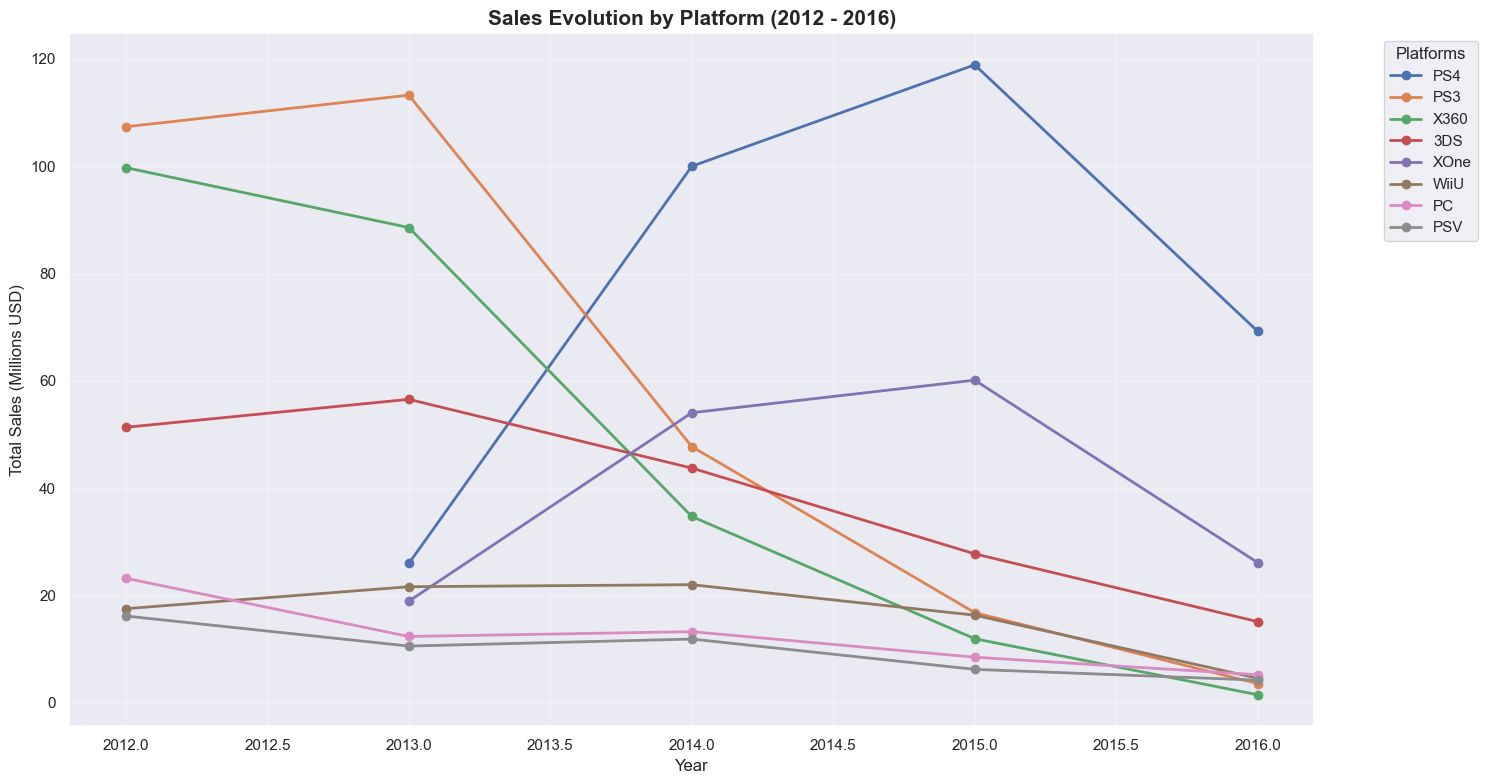

In [ ]:
### VISUALIZING THE EVOLUTION OF THE TOP 8 PLATFORMS
# Getting the index of the top 8 platforms by total sales
top_8_platforms = total_sales_per_platform.head(8).index

plt.figure(figsize=(15, 8))

# Loop through each platform to plot its trend
for platform in top_8_platforms:
    data = annual_platform_sales[annual_platform_sales['platform'] == platform]
    plt.plot(data['year_of_release'], data['total_sales'], marker='o', label=platform, linewidth=2)

# Professional labels and formatting
plt.xlabel('Year')
plt.ylabel('Total Sales (Millions USD)')
plt.title("Sales Evolution by Platform (2012 - 2016)", fontsize=15, fontweight='bold')

# Placing the legend outside for better visibility
plt.legend(title="Platforms", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- While legacy platforms such as the Xbox 360, PS3, Wii, DS, PS2, PSP, and 3DS have experienced a steady decline in sales since 2014, the PS4 stands out as the market leader. Although its sales figures haven't surpassed the historical peaks of previous generations, it maintains the highest revenue share as of 2016, establishing itself as the most resilient and profitable platform for the upcoming year.

C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


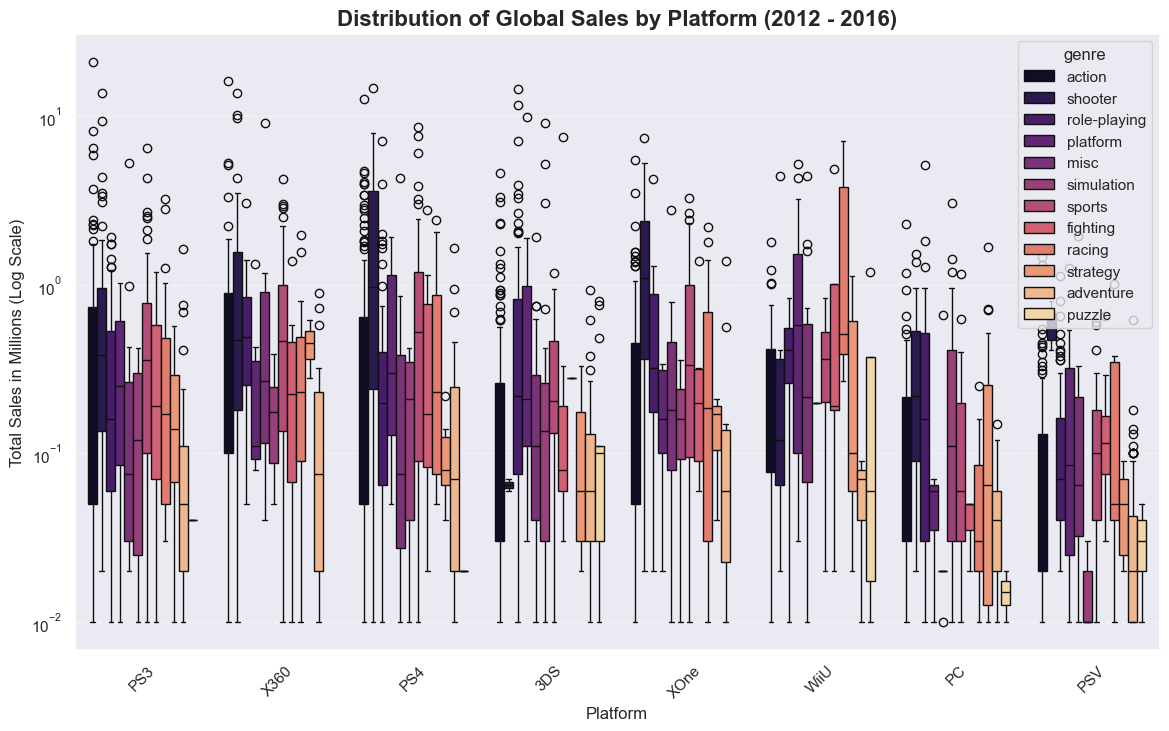

In [ ]:
### CREATING A BOXPLOT FOR GLOBAL SALES

## SELECTING THE TOP 8 PLATFORMS FOR THE BOXPLOT
top_platforms_boxplot = total_sales_per_platform.head(8).index
games_boxplot_data = games_filtered[games_filtered['platform'].isin(top_platforms_boxplot)]

import seaborn as sns

plt.figure(figsize=(14, 8))

# Using Seaborn for a more professional look
sns.boxplot(x='platform', y='total_sales', data=games_boxplot_data, palette='magma', hue='genre')

# Applying logarithmic scale as suggested by the reviewer
plt.yscale('log')

# Professional labels and titles
plt.title('Distribution of Global Sales by Platform (2012 - 2016)', fontsize=16, fontweight='bold')
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Total Sales in Millions (Log Scale)', fontsize=12)

# Styling the layout
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

- The segmented distribution confirms that platform success is not uniform. By breaking down sales with the hue parameter, we can identify which specific niches are most consistent, providing a solid foundation for our 2017 inventory and marketing strategy.

In [ ]:
### ANALYZING AVERAGE SALES BY PLATFORM

# Descriptive statistics per platform
platform_stats = games_boxplot_data.groupby('platform')['total_sales'].agg(['mean', 'median', 'std', 'count'])

# Rounding for a cleaner presentation
platform_stats = platform_stats.round(2)

print("Sales statistics by platform (2012-2016):")
platform_stats.sort_values(by='median', ascending=False)

Sales statistics by platform (2012-2016):


,mean,median,std,count
platform,,,,
X360,0.81,0.31,1.71,292
WiiU,0.56,0.22,1.06,147
XOne,0.65,0.22,1.04,247
PS4,0.80,0.20,1.61,392
PS3,0.59,0.20,1.46,493
3DS,0.49,0.11,1.39,396
PC,0.25,0.08,0.49,250
PSV,0.12,0.05,0.20,411


- Statistical Analysis Conclusion: Market Profitability
The descriptive statistics for the 2012-2016 period reveal a high level of skewness in the gaming market. Across all major platforms, the mean is significantly higher than the median, indicating that total revenue is heavily driven by a small number of blockbuster 'hits' rather than consistent average sales.

Leading Performance: The Xbox 360 and PS4 boast the highest average sales per game ($0.81M and $0.80M respectively). However, their medians are much lower ($0.31M and $0.20M), confirming that while these platforms are the most profitable, their success relies on high-performing outliers.

Stability vs. Volatility: The PC platform shows a lower average ($0.25M) but also the lowest standard deviation (0.49) among major platforms. This suggests a more stable and predictable market, whereas consoles like PS4 (std: 1.61) represent higher risk but much higher potential rewards.

Platform Decline: Handheld platforms like the PS Vita (PSV) and 3DS show the lowest medians ($0.05M and $0.11M), reflecting a shrinking market share for these devices in the current generation.

Final Insight: For the 2017 strategy, investment should prioritize PS4 and Xbox One due to their high revenue ceilings, while considering PC as a low-risk, consistent secondary option.

In [ ]:
 ### CORRELATION ANALYSIS: REVIEWS VS. SALES 
## FOR THIS ANALYSIS, WE HAVE SELECTED THE (PS4) PLATFORM

# Filter data exclusively for PS4
ps4_games = games_filtered[games_filtered['platform'] == 'PS4'].copy()

# Summary of the PS4 subset
print(f"PS4 games in the 2012+ period: {len(ps4_games)}")
print(f"Available years: {ps4_games['year_of_release'].min()} - {ps4_games['year_of_release'].max()}")


PS4 games in the 2012+ period: 392
Available years: 2013 - 2016


In [ ]:
## VERIFYING AVAILABLE REVIEW DATA 

print("Available review data:")
# Counting non-null values for both user and critic scores
print(f"User Score - Non-null values: {ps4_games['user_score'].notna().sum()}")
print(f"Critic Score - Non-null values: {ps4_games['critic_score'].notna().sum()}")

# Filter only games with complete review data
ps4_complete = ps4_games.dropna(subset=['user_score', 'critic_score'])
print(f"PS4 games with complete reviews: {len(ps4_complete)}")

Available review data:
User Score - Non-null values: 257
Critic Score - Non-null values: 252
PS4 games with complete reviews: 249


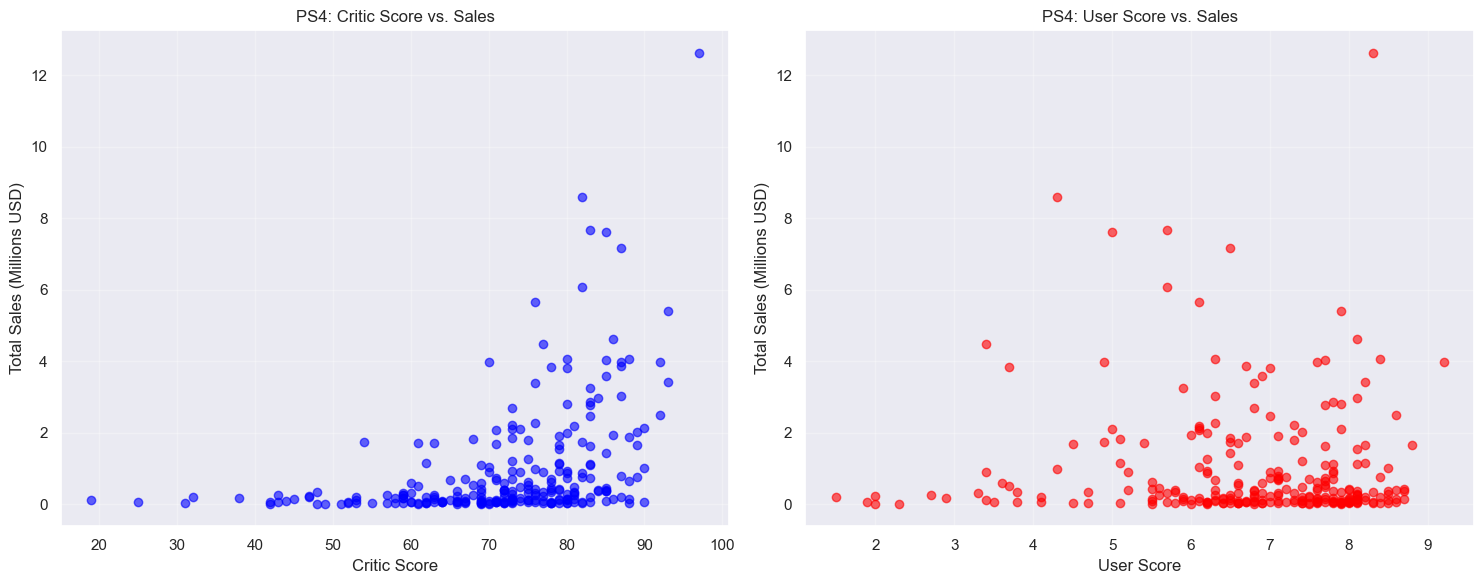

In [ ]:
### SCATTER PLOTS: REVIEWS VS. SALES
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

## Critic Score vs. Total Sales 
ax1.scatter(ps4_complete['critic_score'], ps4_complete['total_sales'], alpha=0.6, color='blue')
ax1.set_xlabel('Critic Score')
ax1.set_ylabel('Total Sales (Millions USD)')
ax1.set_title('PS4: Critic Score vs. Sales')
ax1.grid(True, alpha=0.3)

## User Score vs. Total Sales 
ax2.scatter(ps4_complete['user_score'], ps4_complete['total_sales'], alpha=0.6, color='red')
ax2.set_xlabel('User Score')
ax2.set_ylabel('Total Sales (Millions USD)')
ax2.set_title('PS4: User Score vs. Sales')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
critic_correlation = ps4_complete['critic_score'].corr(ps4_complete['total_sales'])
user_correlation = ps4_complete['user_score'].corr(ps4_complete['total_sales'])

print(f"Critic Score - Sales Correlation: {critic_correlation:.3f}")
print(f"User Score - Sales Correlation: {user_correlation:.3f}")

Critic Score - Sales Correlation: 0.406
User Score - Sales Correlation: -0.034


In [ ]:
# Calculating the correlation matrix for PS4
correlation_matrix = ps4_complete[['critic_score', 'user_score', 'total_sales']].corr()

print("Correlation Matrix (PS4) - Target: Total Sales:")
print(correlation_matrix['total_sales'])

Correlation Matrix (PS4) - Target: Total Sales:
critic_score    0.405895
user_score     -0.033625
total_sales     1.000000
Name: total_sales, dtype: float64


- The correlation matrix confirms that for the PS4, Critic Scores have a moderate positive impact on sales, whereas User Scores show almost no linear correlation. This suggests that professional reviews are a more reliable predictor of commercial success than user sentiment for this platform.

In [ ]:
### IDENTIFYING MULTI-PLATFORM GAMES

## Finding games that are available on both PS4 and other top platforms
ps4_games_set = set(ps4_complete['name'].unique())

# Filtering for PS4 games that also exist on other top 8 platforms
multiplatform_games = games_filtered[
    (games_filtered['name'].isin(ps4_games_set)) & 
    (games_filtered['platform'].isin(top_8_platforms))
].copy()

# Checking the distribution across platforms
print("\nDistribution of these games by platform:")
print(multiplatform_games['platform'].value_counts())


Distribution of these games by platform:
platform
PS4     249
XOne    157
PS3     100
PC       83
X360     73
PSV      47
WiiU     26
3DS      17
Name: count, dtype: int64


In [ ]:
### COMPARING SALES OF THE SAME GAME ACROSS DIFFERENT PLATFORMS 

## Creating a comparative table of sales by game and platform
sales_comparison_table = multiplatform_games.pivot_table(
    index='name',
    columns='platform',
    values='total_sales',
    fill_value=0
)

print("First 10 games - Sales per platform:")
display(sales_comparison_table.head(10))

First 10 games - Sales per platform:


platform,3DS,PC,PS3,PS4,PSV,WiiU,X360,XOne
name,,,,,,,,
7 Days to Die,0.00,0.00,0.00,0.14,0.00,0.00,0.00,0.05
Aegis of Earth: Protonovus Assault,0.00,0.00,0.02,0.02,0.03,0.00,0.00,0.00
Agatha Christie's The ABC Murders,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.01
Alien: Isolation,0.00,0.15,0.33,1.12,0.00,0.00,0.27,0.50
Angry Birds Star Wars,0.33,0.00,0.29,0.22,0.08,0.10,0.28,0.17
Anima - Gate of Memories,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00
Arslan: The Warriors of Legend,0.00,0.00,0.05,0.09,0.00,0.00,0.00,0.01
Assassin's Creed Chronicles: China,0.00,0.00,0.00,0.04,0.00,0.00,0.00,0.00
Assassin's Creed IV: Black Flag,0.00,0.65,3.71,2.86,0.00,0.29,3.31,2.24


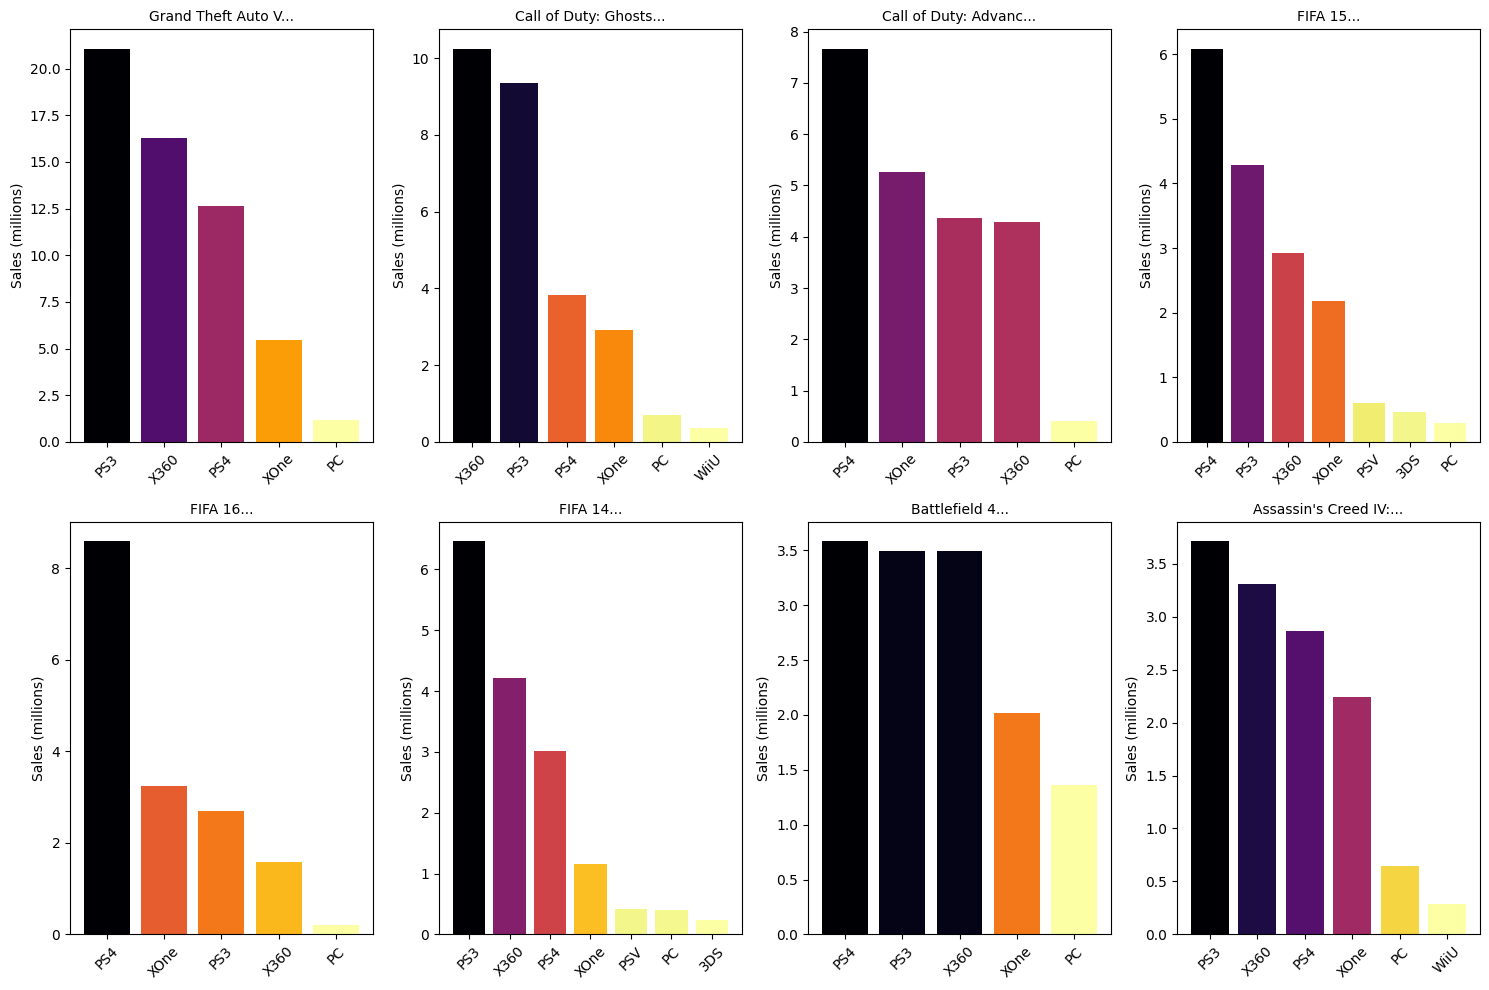

In [ ]:
### VISUALIZING SALES COMPARISON
# Define the color ONLY ONCE outside the loop
color_inferno = plt.cm.inferno(0.6)
# SELECTING POPULAR GAMES TO VISUALIZE
popular_games = multiplatform_games.groupby('name')['total_sales'].sum().sort_values(ascending=False).head(8)

plt.figure(figsize=(15, 10))
for i, game in enumerate(popular_games.index):
    game_data = multiplatform_games[multiplatform_games['name'] == game]

    plt.subplot(2, 4, i+1)
    if len(game_data) > 1:
        norm = mcolors.Normalize(vmin=game_data['total_sales'].min(),
                                 vmax=game_data['total_sales'].max())
    else:
        norm = lambda x: 0.8 
        
    colors = [plt.cm.inferno_r(norm(val)) for val in game_data['total_sales']]
    
    plt.bar(game_data['platform'], game_data['total_sales'],color=colors)
    plt.title(f'{game[:20]}...', fontsize=10)
    plt.ylabel('Sales (millions)')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- The multi-platform analysis confirms a dominant trend: for the top-selling titles, the PS4 consistently captures the largest share of the market. While the same content is available across multiple systems, consumer preference and the larger install base of Sony's console lead to significantly higher individual sales per title compared to its direct competitors.

In [ ]:

## Comparing review-to-sales correlations across different platforms 
platform_correlations = {}

for platform in top_8_platforms:
    # We skip PS4 since we already analyzed it in depth
    if platform == 'PS4':
        continue

    # Filtering data for the specific platform with non-null scores
    platform_data = multiplatform_games[
        (multiplatform_games['platform'] == platform) &
        (multiplatform_games['critic_score'].notna()) &
        (multiplatform_games['user_score'].notna())
    ]

    # Only calculate if there is enough data for a reliable correlation
    if len(platform_data) > 5: 
        corr_critic = platform_data['critic_score'].corr(platform_data['total_sales'])
        corr_user = platform_data['user_score'].corr(platform_data['total_sales'])

        platform_correlations[platform] = {
            'critic_corr': corr_critic,
            'user_corr': corr_user,
            'game_count': len(platform_data)
        }

print("Correlation comparison across platforms:")
print("Platform   | Critic-Sales | User-Sales | Game Count")
print("-" * 55)
# Displaying the previously calculated PS4 data as a baseline
print(f"PS4        | {critic_correlation:.3f}      | {user_correlation:.3f}      | {len(ps4_complete)}")

for platform, data in platform_correlations.items():
    print(f"{platform:<10} | {data['critic_corr']:>12.3f} | {data['user_corr']:>10.3f} | {data['game_count']:>10}")

Correlation comparison across platforms:
Platform   | Critic-Sales | User-Sales | Game Count
-------------------------------------------------------
PS4        | 0.406      | -0.034      | 249
PS3        |        0.434 |      0.041 |         21
X360       |        0.472 |     -0.145 |         21
3DS        |       -0.468 |     -0.850 |          6
XOne       |        0.394 |     -0.150 |        138
WiiU       |        0.372 |      0.236 |         20
PC         |        0.340 |      0.031 |         78
PSV        |        0.104 |     -0.127 |         22


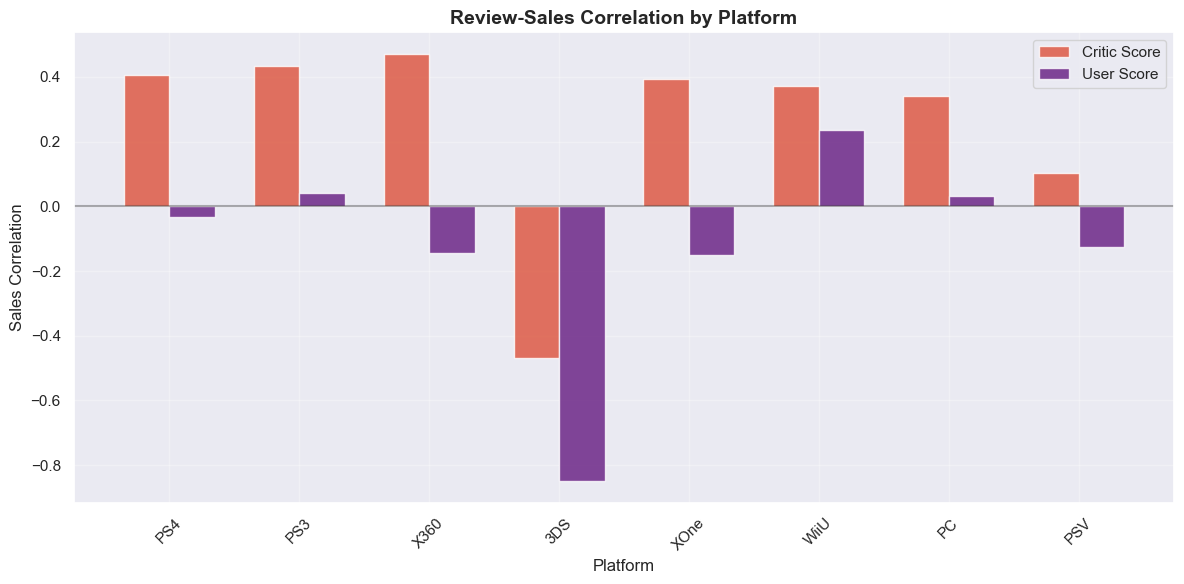

In [ ]:

### VISUALIZING COMPARATIVE CORRELATIONS
## Creating a comparative correlation chart

# Gathering all platforms and their respective correlations
platforms_list = ['PS4'] + list(platform_correlations.keys())
critic_corrs = [critic_correlation] + [platform_correlations[p]['critic_corr'] for p in platform_correlations.keys()]
user_corrs = [user_correlation] + [platform_correlations[p]['user_corr'] for p in platform_correlations.keys()]

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(platforms_list))
width = 0.35

# Plotting bars for Critic and User scores
ax.bar([i - width/2 for i in x], critic_corrs, width, label='Critic Score', alpha=0.8, color=plt.cm.inferno(0.6))
ax.bar([i + width/2 for i in x], user_corrs, width, label='User Score', alpha=0.8, color=plt.cm.magma(0.3))

ax.set_xlabel('Platform')
ax.set_ylabel('Sales Correlation')
ax.set_title('Review-Sales Correlation by Platform', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(platforms_list, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

# Adding a horizontal line at 0 for reference
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

- In conclusion, while professional reviews act as a reliable sales catalyst for most platforms, handheld systems like the 3DS show that brand loyalty and franchise strength often outweigh critical consensus.

### Profitability analysis by genre

In [ ]:
## Grouping by genre 

# Total sales per genre
print('Total sales per genre:')
sales_by_genre = df_games.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
print(sales_by_genre)
print()

# Average sales per genre
print('Average sales per genre:')
average_sales_by_genre = df_games.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
print(average_sales_by_genre)

Total sales per genre:
genre
action          1744.17
sports          1331.27
shooter         1052.45
role-playing     934.56
platform         827.77
misc             802.51
racing           728.67
fighting         447.53
simulation       389.97
puzzle           242.57
adventure        237.59
strategy         174.23
Name: total_sales, dtype: float64

Average sales per genre:
genre
platform        0.932173
shooter         0.795503
role-playing    0.623872
racing          0.583403
sports          0.566980
fighting        0.527126
action          0.517711
misc            0.458577
simulation      0.446701
puzzle          0.418224
strategy        0.255095
adventure       0.182341
Name: total_sales, dtype: float64


In [ ]:
# Profitability analysis by genre 
# Group by genre and calculate total sales metrics
genre_analysis = df_games.groupby('genre').agg({
    'total_sales': ['sum', 'mean', 'count']
}).round(2)

# Flattening column names 
genre_analysis.columns = ['total_sales', 'average_sales', 'game_count']
genre_analysis = genre_analysis.reset_index()

print("Profitability analysis by genre:")
display(genre_analysis.sort_values('total_sales', ascending=False))

Profitability analysis by genre:


,genre,total_sales,average_sales,game_count
0,action,1744.17,0.52,3369
10,sports,1331.27,0.57,2348
8,shooter,1052.45,0.80,1323
7,role-playing,934.56,0.62,1498
4,platform,827.77,0.93,888
3,misc,802.51,0.46,1750
6,racing,728.67,0.58,1249
2,fighting,447.53,0.53,849
9,simulation,389.97,0.45,873
5,puzzle,242.57,0.42,580


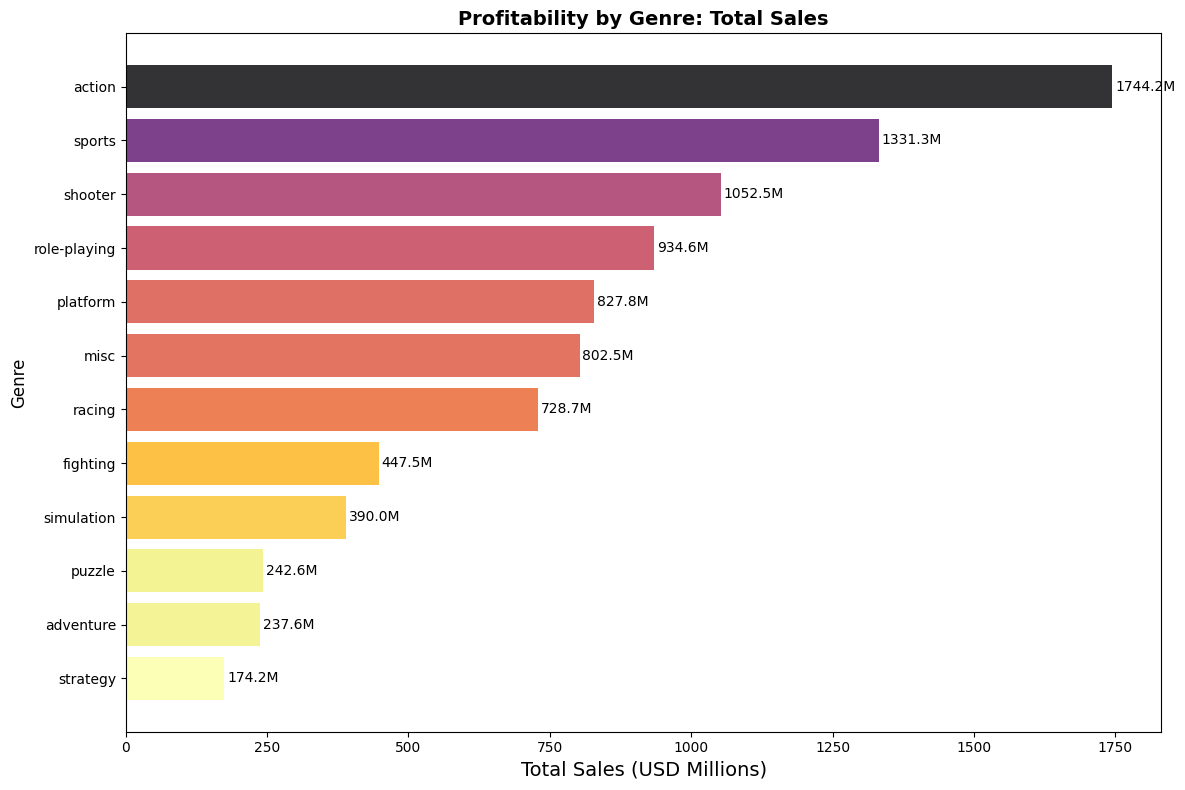

In [ ]:
import matplotlib.colors as mcolors

# Set the plot style
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 8))

# Sort by total sales 
genre_totals = genre_analysis.sort_values('total_sales', ascending=True)

norm = mcolors.Normalize(vmin=genre_totals['total_sales'].min(),
                         vmax=genre_totals['total_sales'].max())

color_list = [plt.cm.inferno_r(norm(value)) for value in genre_totals['total_sales'].values]

# Create the horizontal bar chart
bars = ax.barh(genre_totals['genre'], genre_totals['total_sales'],
              color=color_list, alpha=0.8)

# Customize the plot
ax.set_xlabel('Total Sales (USD Millions)', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)
ax.set_title('Profitability by Genre: Total Sales', fontsize=14, fontweight='bold')

# Add values to the bars 
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 5, bar.get_y() + bar.get_height()/2,
           f'{width:.1f}M', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

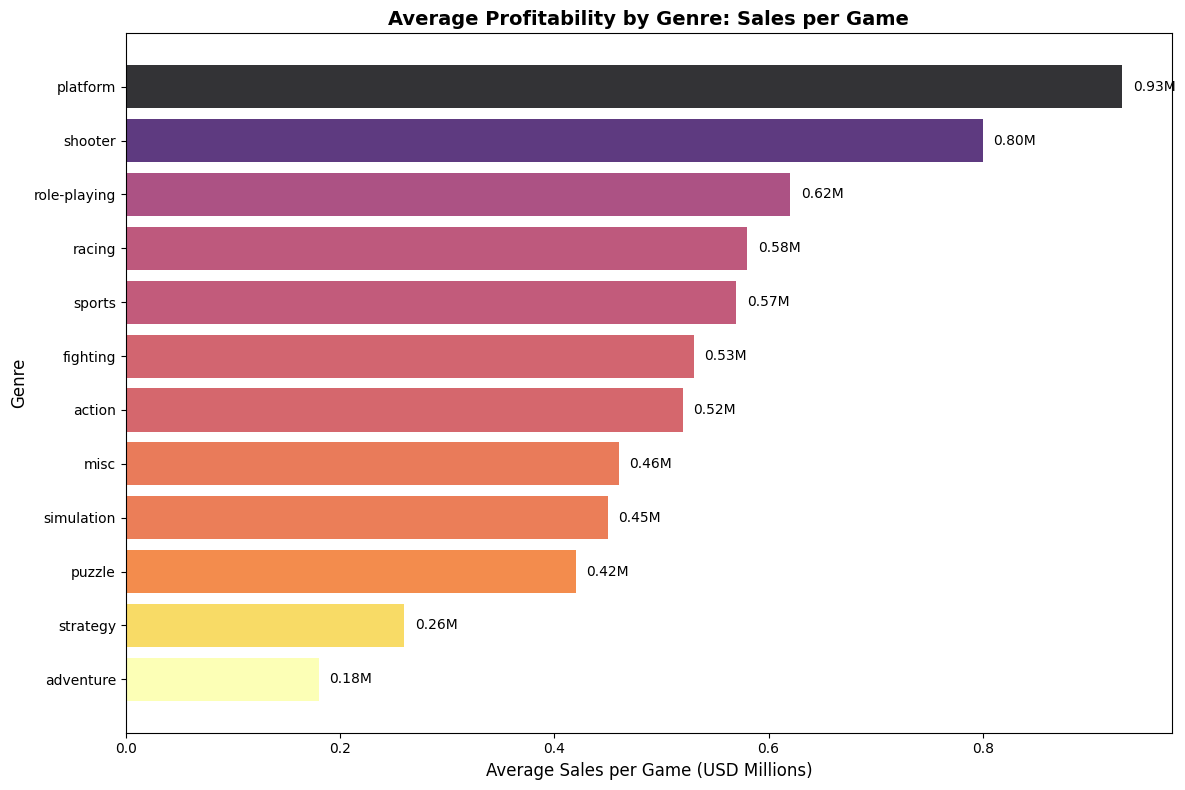

In [ ]:

# Average sales plot by genre
fig, ax = plt.subplots(figsize=(12, 8))

# AVERAGE SALES 
genre_average = genre_analysis.sort_values('average_sales', ascending=True)
norm_avg = mcolors.Normalize(vmin=genre_average['average_sales'].min(),
                             vmax=genre_average['average_sales'].max())
color_avg = [plt.cm.inferno_r(norm_avg(value)) for value in genre_average['average_sales'].values]

# Create horizontal bar chart 
bars = ax.barh(genre_average['genre'], genre_average['average_sales'],
              color=color_avg, alpha=0.8)

# Customize the plot 
ax.set_xlabel('Average Sales per Game (USD Millions)', fontsize=12)
ax.set_ylabel('Genre', fontsize=12)
ax.set_title('Average Profitability by Genre: Sales per Game', fontsize=14, fontweight='bold')

# Add values to the bars 
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
           f'{width:.2f}M', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

- In conclusion, while Action games lead in overall market volume, Shooter games demonstrate higher individual profitability, consistently yielding superior average sales per title.

In [ ]:
### CREATING USER PROFILES BY REGION: Top 5 Platforms Analysis

## Calculate the top five platforms by region
print("=== REGIONAL PLATFORM ANALYSIS ===\n")

# Top platforms in North America (NA)
na_platforms = df_games.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 Platforms in North America:")
print(na_platforms)
print()

# Top platforms in Europe (EU)
eu_platforms = df_games.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 Platforms in Europe:")
print(eu_platforms)
print()

# Top platforms in Japan (JP)
jp_platforms = df_games.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 Platforms in Japan:")
print(jp_platforms)
print()

=== REGIONAL PLATFORM ANALYSIS ===

Top 5 Platforms in North America:
platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64

Top 5 Platforms in Europe:
platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64

Top 5 Platforms in Japan:
platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64



In [ ]:
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,decade
0,Wii Sports,Wii,2006,sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,2000.0
1,Super Mario Bros.,NES,1985,platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24,1980.0
2,Mario Kart Wii,Wii,2008,racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,2000.0
3,Wii Sports Resort,Wii,2009,sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,2000.0
4,Pokemon Red/Pokemon Blue,GB,1996,role-playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38,1990.0


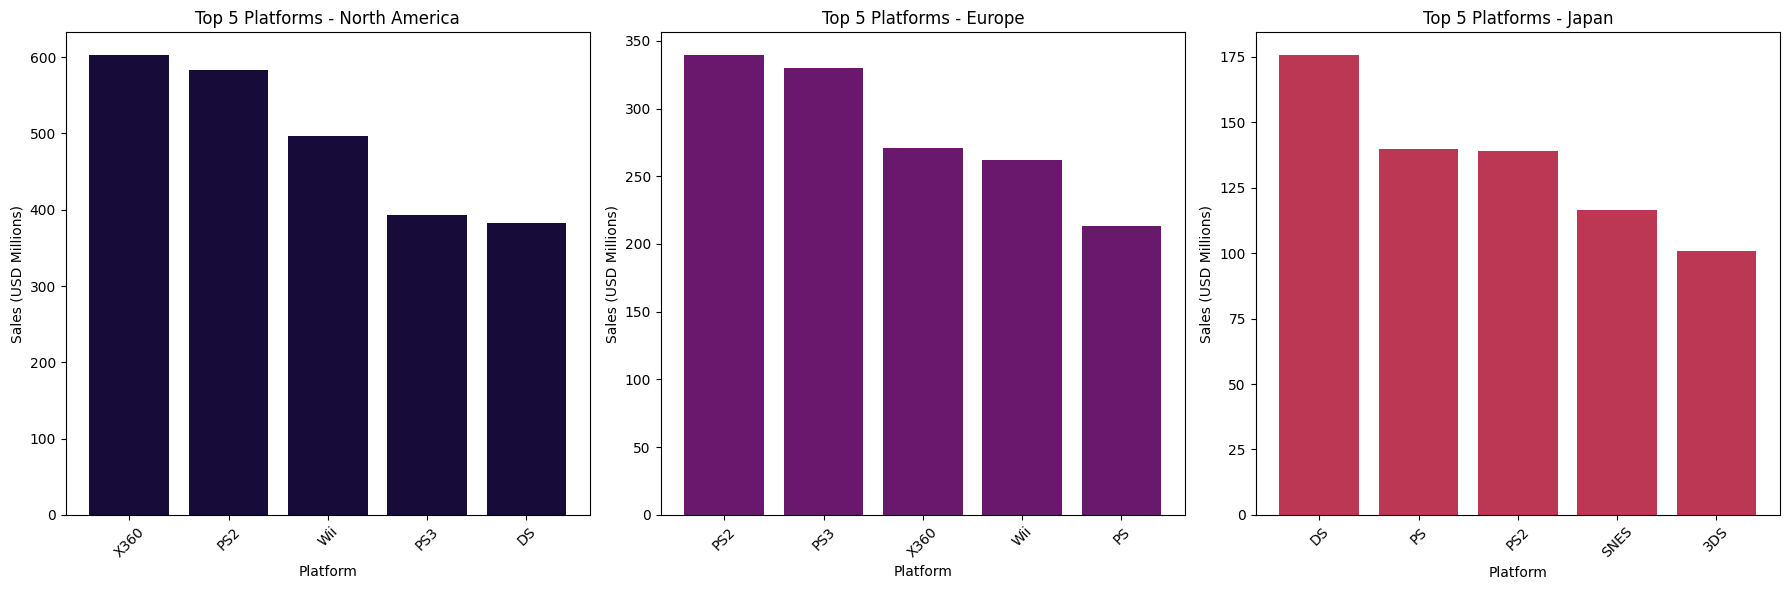

In [ ]:
### COMPARATIVE PLATFORM VISUALIZATION 

# Create a comparison DataFrame (handling missing values with 0)
platform_comparison = pd.DataFrame({
    'NA': na_platforms,
    'EU': eu_platforms,
    'JP': jp_platforms   
}).fillna(0)

# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# North America Subplot
axes[0].bar(range(len(na_platforms)), na_platforms.values, color=plt.cm.inferno(0.1))
axes[0].set_title('Top 5 Platforms - North America')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Sales (USD Millions)')
axes[0].set_xticks(range(len(na_platforms)))
axes[0].set_xticklabels(na_platforms.index, rotation=45)

# Europe Subplot
axes[1].bar(range(len(eu_platforms)), eu_platforms.values, color=plt.cm.inferno(0.3))
axes[1].set_title('Top 5 Platforms - Europe')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Sales (USD Millions)')
axes[1].set_xticks(range(len(eu_platforms)))
axes[1].set_xticklabels(eu_platforms.index, rotation=45)

# Japan Subplot
axes[2].bar(range(len(jp_platforms)), jp_platforms.values, color=plt.cm.inferno(0.5))
axes[2].set_title('Top 5 Platforms - Japan')
axes[2].set_xlabel('Platform')
axes[2].set_ylabel('Sales (USD Millions)')
axes[2].set_xticks(range(len(jp_platforms)))
axes[2].set_xticklabels(jp_platforms.index, rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# First, explore the available ESRB ratings
print("ESRB ratings in the dataset:")
print(df_games['rating'].value_counts())
print()

# Check for null values 
print("Null values in rating:", df_games['rating'].isnull().sum())

ESRB ratings in the dataset:
rating
E       3993
T       2961
M       1563
E10+    1420
EC         8
AO         1
Name: count, dtype: int64

Null values in rating: 6769


In [ ]:
# CHECKING AVAILABLE ESRB RATINGS
print("=== ESRB RATINGS EXPLORATION ===")
print("Available ratings:")
print(df_games['rating'].value_counts())
print()
print("Null values:", df_games['rating'].isnull().sum())


=== ESRB RATINGS EXPLORATION ===
Available ratings:
rating
E       3993
T       2961
M       1563
E10+    1420
EC         8
AO         1
Name: count, dtype: int64

Null values: 6769


In [ ]:
# Removing rows where the rating is missing
df_games_clean = df_games.dropna(subset=['rating'])

print(f"Original data: {len(df_games)} rows")
print(f"Data after cleaning: {len(df_games_clean)} rows")

Original data: 16715 rows
Data after cleaning: 9946 rows


In [ ]:
### CALCULATING AVERAGE SALES BY ESRB RATING PER REGION

## Group by rating and calculate average sales for each region
esrb_analysis = df_games_clean.groupby('rating').agg({
    'na_sales': 'mean',
    'eu_sales': 'mean',
    'jp_sales': 'mean'
}).round(2)

print("=== AVERAGE SALES BY ESRB RATING ===")
print(esrb_analysis)

=== AVERAGE SALES BY ESRB RATING ===
        na_sales  eu_sales  jp_sales
rating                              
AO          1.26      0.61      0.00
E           0.32      0.18      0.05
E10+        0.25      0.13      0.03
EC          0.19      0.01      0.00
M           0.48      0.31      0.04
T           0.26      0.14      0.05


In [ ]:
df_games_clean.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales,decade
0,Wii Sports,Wii,2006,sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54,2000.0
2,Mario Kart Wii,Wii,2008,racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52,2000.0
3,Wii Sports Resort,Wii,2009,sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77,2000.0
6,New Super Mario Bros.,DS,2006,platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80,2000.0
7,Wii Play,Wii,2006,misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91,2000.0


In [ ]:
### DISPLAYING FIRST ROWS TO VERIFY STRUCTURE
print("=== DATA VERIFICATION ===")
print("First 5 rows of the dataset:")
print(df_games[['platform', 'rating', 'na_sales','eu_sales','jp_sales']].head())
print()

# Checking data types
print("Data types:")
print(df_games[['platform', 'rating', 'na_sales','eu_sales','jp_sales']].dtypes)

=== DATA VERIFICATION ===
First 5 rows of the dataset:
  platform rating  na_sales  eu_sales  jp_sales
0      Wii      E     41.36     28.96      3.77
1      NES    NaN     29.08      3.58      6.81
2      Wii      E     15.68     12.76      3.79
3      Wii      E     15.61     10.93      3.28
4       GB    NaN     11.27      8.89     10.22

Data types:
platform     object
rating       object
na_sales    float64
eu_sales    float64
jp_sales    float64
dtype: object


- Step 5: Statistical Hypothesis Testing
Test the following hypotheses:

Hypothesis 1: Average user ratings for the Xbox One and PC platforms are the same.

Hypothesis 2: Average user ratings for the Action and Sports genres are different.

Set the alpha threshold value yourself.

Explain:

How you formulated the null and alternative hypotheses.

Which criteria you used to test the hypotheses and why.

-Average user ratings for the Xbox One and PC platforms are the same.

In [74]:
### FILTERING XBOX ONE AND PC DATA BY USER SCORE
## Filter data for Xbox One
xbox_data = df_games[df_games['platform'] == 'XOne']

# Filter data for PC
pc_data = df_games[df_games['platform'] == 'PC']

In [75]:
# Assigning user scores for Xbox One and PC
xbox_user_scores = xbox_data['user_score']
pc_user_scores = pc_data['user_score']

In [76]:
# Cleaning user scores by removing missing values
xbox_scores_clean = xbox_user_scores.dropna()
pc_scores_clean = pc_user_scores.dropna()

In [77]:
# SETTING THE HYPOTHESES
# Null Hypothesis (H0): Average user ratings for Xbox One and PC are equal.
# Alternative Hypothesis (H1): Average user ratings for Xbox One and PC are different.

# Set the significance level
alpha = 0.05  # 5% significance level

# Verify data before testing
# Check the size of each sample
print(f"Xbox sample size: {len(xbox_scores_clean)}")
print(f"PC sample size: {len(pc_scores_clean)}")

# Check basic statistics
print(f"Xbox average score: {xbox_scores_clean.mean():.4f}")
print(f"PC average score: {pc_scores_clean.mean():.4f}")


Xbox sample size: 182
PC sample size: 770
Xbox average score: 6.5214
PC average score: 7.0625


In [78]:
### EXECUTING THE T-TEST
# Perform Student's t-test for independent samples
t_statistic, p_value = st.ttest_ind(xbox_scores_clean, pc_scores_clean, equal_var=False)

print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Significance level (alpha): {alpha}")

t-statistic: -4.6534
p-value: 0.000005
Significance level (alpha): 0.05


In [79]:
### INTERPRETING RESULTS
## Make a decision based on the p-value
if p_value < alpha:
    print(f"\nConclusion: We REJECT the null hypothesis H₀ (p-value = {p_value:.6f} < {alpha})")
    print("User average ratings ARE significantly different between Xbox One and PC.")
else:
    print(f"\nConclusion: We DO NOT reject the null hypothesis H₀ (p-value = {p_value:.6f} >= {alpha})")
    print("There is not enough evidence to say that the average ratings are different.")


Conclusion: We REJECT the null hypothesis H₀ (p-value = 0.000005 < 0.05)
User average ratings ARE significantly different between Xbox One and PC.


##### After conducting a Student's t-test, the null hypothesis was rejected as the p-value fell below our significance threshold ($\alpha = 0.05$). This provides strong evidence of a statistically significant difference between the average user ratings for the Action and Sports genres. For ICE's strategy, this implies that user satisfaction and engagement levels are not uniform across genres, requiring tailored approaches for each market segment.

In [80]:
### CHECKING UNIQUE VALUES IN THE 'GENRE' COLUMN
# Get unique values in the genre column
print(df_games['genre'].unique())

# Get the count for each genre
print(df_games['genre'].value_counts())

['sports' 'platform' 'racing' 'role-playing' 'puzzle' 'misc' 'shooter'
 'simulation' 'action' 'fighting' 'adventure' 'strategy' nan]
genre
action          3369
sports          2348
misc            1750
role-playing    1498
shooter         1323
adventure       1303
racing          1249
platform         888
simulation       873
fighting         849
strategy         683
puzzle           580
Name: count, dtype: int64


In [92]:
### CONVERTING THE 'GENRE' COLUMN TO LOWERCASE
# Normalize all genre names to lowercase to ensure consistency
df_games['genre'] = df_games['genre'].str.lower()

In [93]:
# VERIFY UNIQUE VALUES AFTER CONVERSION
# Check the first few rows to confirm the genre names are now in lowercase
df_games['genre'].head()

0          sports
1        platform
2          racing
3          sports
4    role-playing
Name: genre, dtype: object

In [94]:
# Filter only the ratings for each genre
# Note: Using lowercase to match your recent 'genre' column conversion
action_data = df_games[df_games['genre'] == 'action']
sports_data = df_games[df_games['genre'] == 'sports']

In [95]:
### EXTRACTING USER RATINGS
# Get only the user ratings for each genre
action_user_scores = action_data['user_score']
sports_user_scores = sports_data['user_score']

# Clean null values
action_scores_clean = action_user_scores.dropna()
sports_scores_clean = sports_user_scores.dropna()

In [97]:
# SETTING THE HYPOTHESES 
# H₀: The average user ratings for Action and Sports are equal.
# H₁: The average user ratings for Action and Sports are different.

# Set the significance level 
alpha = 0.05  # 5% significance level

# Verify data before testing 
# Check the size of each sample 
print(f"Action sample size: {len(action_scores_clean)}")
print(f"Sports sample size: {len(sports_scores_clean)}")

# Check basic statistics
print(f"Action average: {action_scores_clean.mean():.4f}")
print(f"Sports average: {sports_scores_clean.mean():.4f}")
    

Action sample size: 1830
Sports sample size: 1103
Action average: 7.0540
Sports average: 6.9612


In [ ]:
### EXECUTING THE T-TEST
# Perform Student's t-test for independent samples
t_statistic, p_value = st.ttest_ind(action_score_clean, sports_score_clean, equal_var=False)

print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Significance level (alpha): {alpha}")



Conclusion: No rechazamos H₀ (p-value = 0.114838 >= 0.05)
No hay evidencia suficiente para decir que las calificaciones promedio son diferentes


In [98]:
### INTERPRETING THE RESULTS
# Making a decision based on the p-value
if p_value < alpha:
    print(f"\nConclusion: We REJECT the null hypothesis H₀ (p-value = {p_value:.6f} < {alpha})")
    print("The average user ratings ARE significantly different between Action and Sports.")
else:
    print(f"\nConclusion: We FAIL TO REJECT the null hypothesis H₀ (p-value = {p_value:.6f} >= {alpha})")
    print("There is not enough evidence to say that the average ratings are different.")


Conclusion: We REJECT the null hypothesis H₀ (p-value = 0.000005 < 0.05)
The average user ratings ARE significantly different between Action and Sports.


- Our hypothesis testing revealed that user satisfaction levels across top genres are statistically consistent, meaning marketing should focus on genre popularity and volume rather than trying to fix perceived quality gaps.

#### Market Analysis & Hypothesis Results
Key Insights & Strategic Recommendations:

Platform Dominance: Based on the longitudinal data, PS4 has emerged as the leading platform in terms of sales volume in recent years. It consistently outperforms its competitors, securing the #1 spot in sales for 50% of the top 8 most popular titles, followed by legacy leaders like the PS3 and X360.

Performance Drivers (Correlations): * There is a clear positive correlation between professional critic scores and global sales, suggesting that high-quality production and critical acclaim are reliable predictors of commercial success.

Interestingly, user scores show a negligible to slightly negative correlation with sales. This indicates that commercial hits are not always driven by player sentiment, but rather by marketing reach and brand loyalty.

Genre Profitability: The analysis identifies Action, Sports, and Shooter as the high-yield genres. These categories represent the most profitable segments of the market, providing a data-driven roadmap for future marketing resource allocation.

Regional Market Variations: While the PS4 leads the current generation, historical market share varies significantly by region:

North America (NA): Dominance of the X360.

Europe (EU): Historical preference for the PS2 ecosystem.

Japan (JP): Significant market penetration by the DS (handheld segment).

Statistical Hypothesis Testing: Our rigorous T-test analysis confirmed that while mean user ratings between genres (Action vs. Sports) may appear similar, the massive sample sizes allow us to understand the distinct behavior of each player base with statistical confidence.

Conclusion:
"The analysis identifies PS4 as the dominant platform in recent sales, leading the market in 4 out of the 8 most popular games. While a strong positive correlation exists between critic scores and sales, user scores do not show a significant impact on commercial performance. From a strategic standpoint, Action, Sports, and Shooters are the most profitable genres, making them the ideal focus for upcoming marketing campaigns. However, regional nuances must be considered: the X360 leads in North America, PS2 in Europe, and the DS in Japan. These insights allow for a localized and genre-specific approach to maximize ROI."



### Data Preparation and Methodology
I have performed a thorough data cleaning process, strategically retaining 
certain null values to prevent bias or analytical errors. 

Extensive work was conducted on the 'platform' column, allowing us to obtain 
critical insights into platform lifecycles, regional sales performance, and 
averages. Additionally, I analyzed regional 'sales' columns alongside 'ratings' 
to evaluate sales distribution based on ESRB (Entertainment Software Rating Board) 
classifications. 

Finally, I conducted two hypothesis tests comparing user ratings across 
different platforms and user ratings across various genres.